## Numbers Dataset

We have a dataset of handwritten digits from 0 to 9

We need some library to read the images, I've chosen the pillow library which comes with Anaconda, if you need to 

pip install Pillow

should install it for you

In [1]:
# =====================================================================
# IMPORTS
# =====================================================================
# numpy: numerical operations and array manipulation
# glob: file pattern matching to find all image files
# matplotlib: plotting and visualisation
# PIL (Pillow): reading image files into arrays
# pandas: data manipulation (used here for sampling examples)
# =====================================================================
import numpy as np
import glob
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

In [2]:
## Printing Examples
# Helper function to display a grid of sample images from each digit class.
# X: feature matrix (each row is a flattened 20x20 image = 400 features)
# y: labels (0-9)
# examples_per_class: how many examples to show per digit
# number_of_classes: total digit classes (10 for 0-9)
# mult: multiplier to rescale pixel values back for display
def printexamples(X, y, examples_per_class = 10, number_of_classes = 10, mult = 1.0):
    pos = 0
    data = pd.DataFrame(y, columns=["yvalue"])
    for cls in range(number_of_classes):
        this_class = data[data["yvalue"] == cls]
        idxs = this_class.sample(examples_per_class).index
        for i, idx in enumerate(idxs):
            plt.subplot(examples_per_class, number_of_classes, i * number_of_classes + cls + 1)
            # Reshape the flat 400-element vector back to 20x20 image for display
            plt.imshow((X[idx]*mult).reshape(20,20).astype('uint8'), cmap='gray')
            plt.axis('off')
            if i == 0:
                plt.title(str(cls))
    plt.show()

In [3]:
# =====================================================================
# DATA LOADING
# =====================================================================
# glob finds all .png files inside data/*/  (each subfolder is a digit label)
# e.g. data/0/img001.png, data/3/img042.png, etc.
filelist = glob.glob('data/*/*.png') 

# Load all images:
# - Open each image with Pillow, convert to numpy array
# - Flatten the 20x20 image into a 400-element 1D vector (one feature per pixel)
# This creates our feature matrix X of shape (n_samples, 400)
X = np.array([np.array(Image.open(fname)).flatten() for fname in filelist])   

# Extract labels from the folder name in the file path
# e.g. 'data/3/img001.png'.split('/')[-2] gives '3'
y = (np.array([int(fname.split('/')[-2]) for fname in filelist]))

In [4]:
# Quick check: see what labels look like
y

array([3, 3, 3, ..., 7, 7, 7], shape=(5000,))

In [5]:
# Check the shape of our data
# X should be (5000, 400) -> 5000 images, each flattened to 400 pixels
# y should be (5000,) -> one label per image
print("x shape:", X.shape)
print("y shape:", y.shape)

x shape: (5000, 400)
y shape: (5000,)


### What range of values do the pixels take?
The pixels should range from 0 to 255.

In [6]:
# =====================================================================
# FEATURE SCALING (Normalisation)
# =====================================================================
# Scale pixel values from [0, 255] to [0, 1] by dividing by 255.
# WHY: Many ML algorithms (especially SVM, kNN, logistic regression)
# perform better and converge faster when features are on a similar scale.
# Since all features are pixels with the same original range, simple
# min-max scaling by /255 is appropriate here.
# =====================================================================
X = X / 255.0

In [7]:
# Verify shapes are unchanged after scaling
print("x shape:", X.shape)
print("y shape:", y.shape)

x shape: (5000, 400)
y shape: (5000,)


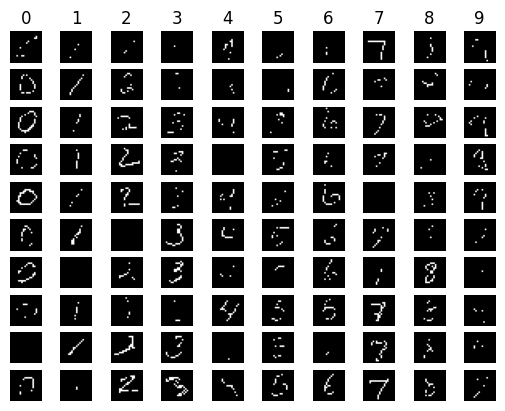

In [8]:
# Visualise some example digits from each class
printexamples(X, y)

In [9]:
# =====================================================================
# TRAIN / VALIDATION / TEST SPLIT
# =====================================================================
# We split the data into three sets:
#   - Training set (60%):   used to train models
#   - Validation set (20%): used to tune hyperparameters and compare models
#   - Test set (20%):       held out until the very end for final evaluation
#
# stratify=y ensures each split has the same proportion of each digit class
# random_state=1138 ensures reproducibility
#
# Step 1: Split off 20% as test set
# Step 2: Split the remaining 80% into 75% train / 25% valid
#          (0.25 of 80% = 20% of total)
# Result: 60% train, 20% valid, 20% test
# =====================================================================
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, random_state=1138, stratify=y, test_size=0.2
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, random_state=1138, stratify=y_temp, test_size=0.25
)

In [10]:
# Verify split sizes
print("Training set shape:", X_train.shape)   # expect (3000, 400)
print("Validation set shape:", X_valid.shape)  # expect (1000, 400)
print("Test set shape:", X_test.shape)          # expect (1000, 400)

Training set shape: (3000, 400)
Validation set shape: (1000, 400)
Test set shape: (1000, 400)


---
## Model 1: Linear Support Vector Machine (SVM)

**How it works:** SVM finds the hyperplane(s) that best separate classes by maximising the margin between them. A linear kernel means the decision boundary is a straight line (or hyperplane in high dimensions).

**Key hyperparameter:**
- `C` (regularisation): Controls the trade-off between a wide margin and misclassifications. Small C → more regularisation (simpler model, wider margin). Large C → less regularisation (fits training data more tightly, narrower margin).

In [11]:
# =====================================================================
# LINEAR SVM - Initial fit with default C=1.0
# =====================================================================
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

# Create a linear SVM classifier
# kernel='linear' means we use a linear decision boundary
model_svc = SVC(kernel='linear')

# Fit the model on training data only
model_svc.fit(X_train, y_train)

# Evaluate on validation set (data the model has NOT seen during training)
print("Validation accuracy:", model_svc.score(X_valid, y_valid))

# Evaluate on training set (should be higher — if much higher, signals overfitting)
print("Training accuracy:", model_svc.score(X_train, y_train))

# Generate predictions on validation set for detailed evaluation
y_pred_svc = model_svc.predict(X_valid)

# Confusion matrix: rows = actual class, columns = predicted class
# Diagonal = correct predictions; off-diagonal = misclassifications
# Useful for seeing WHICH digits get confused with each other
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, y_pred_svc))

# Classification report gives per-class precision, recall, F1-score:
# - Precision: of all predictions for digit X, what fraction were correct?
# - Recall: of all actual digit X samples, what fraction did we find?
# - F1-score: harmonic mean of precision and recall (balances both)
print("\nClassification Report:")
print(classification_report(y_valid, y_pred_svc))

Validation accuracy: 0.904
Training accuracy: 0.998

Confusion Matrix:
[[98  0  0  0  0  2  0  0  0  0]
 [ 0 98  0  0  1  0  0  0  1  0]
 [ 1  1 88  0  4  0  2  1  3  0]
 [ 0  1  1 88  0  6  0  1  1  2]
 [ 0  0  0  0 98  0  1  0  0  1]
 [ 0  0  0  9  0 90  0  0  0  1]
 [ 1  0  2  0  2  3 91  0  1  0]
 [ 2  4  1  0  4  0  0 84  1  4]
 [ 0  1  1  2  1 11  0  0 83  1]
 [ 1  0  1  0  8  1  0  2  1 86]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       100
           1       0.93      0.98      0.96       100
           2       0.94      0.88      0.91       100
           3       0.89      0.88      0.88       100
           4       0.83      0.98      0.90       100
           5       0.80      0.90      0.85       100
           6       0.97      0.91      0.94       100
           7       0.95      0.84      0.89       100
           8       0.91      0.83      0.87       100
           9       0.91      0.86

In [12]:
# =====================================================================
# HYPERPARAMETER TUNING with GridSearchCV
# =====================================================================
# GridSearchCV tries every value of C and uses 5-fold cross-validation
# on the TRAINING set to estimate performance for each C value.
#
# Cross-validation: splits training data into 5 folds, trains on 4,
# validates on 1, rotates through all 5 combinations. Averages the scores.
# This gives a more reliable estimate than a single train/valid split.
#
# We search over a wide range of C values (powers of 10)
# to find the best regularisation strength.
# =====================================================================
from sklearn.model_selection import GridSearchCV

param_grid_svc = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# cv=5 means 5-fold cross-validation
# scoring='accuracy' is the metric used to select the best C
grid_svc = GridSearchCV(
    SVC(kernel='linear'),
    param_grid_svc,
    cv=5,
    scoring='accuracy'
)
grid_svc.fit(X_train, y_train)

print("Best C value:", grid_svc.best_params_)
print("Best cross-validation accuracy:", round(grid_svc.best_score_, 4))

Best C value: {'C': 0.1}
Best cross-validation accuracy: 0.9247


In [13]:
# =====================================================================
# RETRAIN SVM WITH BEST C, EVALUATE ON VALIDATION SET
# =====================================================================
# After finding the best C via cross-validation, retrain on the
# full training set with that C and check validation performance.
# =====================================================================
best_C = grid_svc.best_params_['C']
model_svc_tuned = SVC(kernel='linear', C=best_C)
model_svc_tuned.fit(X_train, y_train)

print("Tuned SVM - Validation accuracy:", model_svc_tuned.score(X_valid, y_valid))
print("Tuned SVM - Training accuracy:", model_svc_tuned.score(X_train, y_train))

# Detailed evaluation on validation set
y_pred_svc_tuned = model_svc_tuned.predict(X_valid)
print("\nConfusion Matrix (Tuned SVM):")
print(confusion_matrix(y_valid, y_pred_svc_tuned))
print("\nClassification Report (Tuned SVM):")
print(classification_report(y_valid, y_pred_svc_tuned))

Tuned SVM - Validation accuracy: 0.93
Tuned SVM - Training accuracy: 0.9716666666666667

Confusion Matrix (Tuned SVM):
[[97  0  0  1  0  2  0  0  0  0]
 [ 0 99  0  0  0  0  0  0  1  0]
 [ 0  0 91  0  4  1  1  0  3  0]
 [ 0  1  1 88  0  6  0  2  1  1]
 [ 0  0  0  0 98  0  0  0  0  2]
 [ 0  0  0  4  0 95  0  0  0  1]
 [ 2  0  1  0  3  2 91  0  1  0]
 [ 1  3  0  0  3  0  0 90  1  2]
 [ 0  0  1  2  0  8  0  0 88  1]
 [ 1  0  0  0  4  0  0  1  1 93]]

Classification Report (Tuned SVM):
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       100
           1       0.96      0.99      0.98       100
           2       0.97      0.91      0.94       100
           3       0.93      0.88      0.90       100
           4       0.88      0.98      0.92       100
           5       0.83      0.95      0.89       100
           6       0.99      0.91      0.95       100
           7       0.97      0.90      0.93       100
           8       0.92    

### Which digits are most frequently confused?
Look at the confusion matrix: the largest off-diagonal values show which pairs of digits get mixed up. Typically digits like 3/5, 8/5, 4/9, 7/1 are commonly confused because they share visual features.

### Comment on overfitting:
Training accuracy (~0.998) is much higher than validation accuracy (~0.90). This gap indicates **overfitting** — the model has memorised training data patterns that don't generalise. Tuning C with cross-validation helps mitigate this by finding the right regularisation balance.

---
## Model 2: Random Forest

**How it works:** An ensemble of decision trees, each trained on a random bootstrap sample of the data using a random subset of features. Final prediction is by majority vote across all trees.

**Key hyperparameters:**
- `n_estimators`: number of trees in the forest (more trees = more stable but slower)
- `max_depth`: maximum depth of each tree (controls overfitting)
- `min_samples_split`: minimum samples needed to split a node

In [14]:
# =====================================================================
# RANDOM FOREST - Initial fit with defaults
# =====================================================================
from sklearn.ensemble import RandomForestClassifier

# Default: 100 trees, no max_depth limit, min_samples_split=2
random_forest = RandomForestClassifier(random_state=1138)
random_forest.fit(X_train, y_train)

print("RF Validation accuracy:", random_forest.score(X_valid, y_valid))
print("RF Training accuracy:", random_forest.score(X_train, y_train))

# Predictions and detailed metrics on validation set
y_pred_rf = random_forest.predict(X_valid)

print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_valid, y_pred_rf))

print("\nClassification Report (Random Forest):")
print(classification_report(y_valid, y_pred_rf))

RF Validation accuracy: 0.93
RF Training accuracy: 1.0

Confusion Matrix (Random Forest):
[[98  0  1  0  0  0  0  0  1  0]
 [ 0 98  0  0  2  0  0  0  0  0]
 [ 2  0 94  0  1  0  1  0  2  0]
 [ 0  2  2 88  0  5  0  1  1  1]
 [ 0  0  2  0 97  0  1  0  0  0]
 [ 2  0  0  1  2 92  0  0  0  3]
 [ 1  0  0  0  1  2 94  0  2  0]
 [ 1  3  1  0  3  0  0 86  2  4]
 [ 0  1  0  2  1  4  0  0 91  1]
 [ 2  0  0  0  3  0  0  2  1 92]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       100
           1       0.94      0.98      0.96       100
           2       0.94      0.94      0.94       100
           3       0.97      0.88      0.92       100
           4       0.88      0.97      0.92       100
           5       0.89      0.92      0.91       100
           6       0.98      0.94      0.96       100
           7       0.97      0.86      0.91       100
           8       0.91      0.91      0.91       10

In [15]:
# =====================================================================
# HYPERPARAMETER TUNING FOR RANDOM FOREST
# =====================================================================
# We tune n_estimators and max_depth using GridSearchCV.
# max_depth limits tree growth to reduce overfitting (training acc = 1.0
# with defaults suggests the trees are overfitting heavily).
# =====================================================================
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=1138),
    param_grid_rf,
    cv=5,
    scoring='accuracy'
 )
grid_rf.fit(X_train, y_train)

print("Best RF params:", grid_rf.best_params_)
print("Best RF cross-validation accuracy:", round(grid_rf.best_score_, 4))

Best RF params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best RF cross-validation accuracy: 0.9393


In [16]:
# =====================================================================
# RETRAIN RANDOM FOREST WITH BEST PARAMS
# =====================================================================
best_rf = grid_rf.best_estimator_  # GridSearchCV already refits on full training set

print("Tuned RF - Validation accuracy:", best_rf.score(X_valid, y_valid))
print("Tuned RF - Training accuracy:", best_rf.score(X_train, y_train))

y_pred_rf_tuned = best_rf.predict(X_valid)
print("\nConfusion Matrix (Tuned RF):")
print(confusion_matrix(y_valid, y_pred_rf_tuned))
print("\nClassification Report (Tuned RF):")
print(classification_report(y_valid, y_pred_rf_tuned))

Tuned RF - Validation accuracy: 0.926
Tuned RF - Training accuracy: 1.0

Confusion Matrix (Tuned RF):
[[98  0  1  0  0  0  0  0  1  0]
 [ 0 98  0  0  0  0  1  1  0  0]
 [ 2  0 91  1  2  0  1  1  2  0]
 [ 0  2  1 88  0  5  0  2  1  1]
 [ 0  0  2  0 96  1  1  0  0  0]
 [ 0  0  0  2  1 94  0  0  0  3]
 [ 1  0  1  0  1  3 93  0  1  0]
 [ 1  4  1  0  3  0  0 85  1  5]
 [ 0  1  0  3  1  3  1  0 90  1]
 [ 2  0  0  0  2  0  0  2  1 93]]

Classification Report (Tuned RF):
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       100
           1       0.93      0.98      0.96       100
           2       0.94      0.91      0.92       100
           3       0.94      0.88      0.91       100
           4       0.91      0.96      0.93       100
           5       0.89      0.94      0.91       100
           6       0.96      0.93      0.94       100
           7       0.93      0.85      0.89       100
           8       0.93      0.90      0.91  

---
## Model 3: k-Nearest Neighbours (kNN)

**How it works:** Classifies a new sample by looking at its k nearest neighbours in the training set (using some distance metric, usually Euclidean) and taking a majority vote.

**Key hyperparameters:**
- `n_neighbors` (k): how many neighbours to consider. Small k → more complex/noisy decision boundary. Large k → smoother but potentially too simple.
- `weights`: 'uniform' (all neighbours vote equally) or 'distance' (closer neighbours have more influence).

**Note:** kNN is very sensitive to feature scaling — we already scaled to [0,1] which is essential here.

In [17]:
# =====================================================================
# kNN - Initial fit with k=5 (a common default)
# =====================================================================
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("kNN (k=5) Validation accuracy:", knn.score(X_valid, y_valid))
print("kNN (k=5) Training accuracy:", knn.score(X_train, y_train))

y_pred_knn = knn.predict(X_valid)
print("\nConfusion Matrix (kNN k=5):")
print(confusion_matrix(y_valid, y_pred_knn))
print("\nClassification Report (kNN k=5):")
print(classification_report(y_valid, y_pred_knn))

kNN (k=5) Validation accuracy: 0.921
kNN (k=5) Training accuracy: 0.9573333333333334

Confusion Matrix (kNN k=5):
[[99  0  0  0  0  0  0  0  1  0]
 [ 0 99  0  0  1  0  0  0  0  0]
 [ 0  4 87  1  1  1  1  1  4  0]
 [ 0  3  2 91  0  1  0  0  2  1]
 [ 0  1  1  0 95  0  0  0  0  3]
 [ 1  1  0  0  2 90  0  0  2  4]
 [ 2  1  0  0  0  2 95  0  0  0]
 [ 1  6  0  0  3  0  0 87  0  3]
 [ 1  1  1  4  1  4  1  0 86  1]
 [ 2  1  0  0  3  0  1  1  0 92]]

Classification Report (kNN k=5):
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       100
           1       0.85      0.99      0.91       100
           2       0.96      0.87      0.91       100
           3       0.95      0.91      0.93       100
           4       0.90      0.95      0.92       100
           5       0.92      0.90      0.91       100
           6       0.97      0.95      0.96       100
           7       0.98      0.87      0.92       100
           8       0.91      0.86 

In [18]:
# =====================================================================
# HYPERPARAMETER TUNING FOR kNN
# =====================================================================
# We search over different values of k and weighting schemes.
# 'distance' weighting often helps because closer neighbours should
# be more informative than distant ones.
# =====================================================================
param_grid_knn = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy'
)
grid_knn.fit(X_train, y_train)

print("Best kNN params:", grid_knn.best_params_)
print("Best kNN cross-validation accuracy:", round(grid_knn.best_score_, 4))

Best kNN params: {'n_neighbors': 1, 'weights': 'uniform'}
Best kNN cross-validation accuracy: 0.934


In [19]:
# =====================================================================
# EVALUATE TUNED kNN ON VALIDATION SET
# =====================================================================
best_knn = grid_knn.best_estimator_

print("Tuned kNN - Validation accuracy:", best_knn.score(X_valid, y_valid))
print("Tuned kNN - Training accuracy:", best_knn.score(X_train, y_train))

y_pred_knn_tuned = best_knn.predict(X_valid)
print("\nConfusion Matrix (Tuned kNN):")
print(confusion_matrix(y_valid, y_pred_knn_tuned))
print("\nClassification Report (Tuned kNN):")
print(classification_report(y_valid, y_pred_knn_tuned))

Tuned kNN - Validation accuracy: 0.925
Tuned kNN - Training accuracy: 1.0

Confusion Matrix (Tuned kNN):
[[99  0  0  1  0  0  0  0  0  0]
 [ 0 99  0  0  0  0  0  0  1  0]
 [ 2  2 89  0  1  1  1  0  4  0]
 [ 0  1  1 93  0  0  0  0  4  1]
 [ 0  1  0  0 97  0  1  0  0  1]
 [ 0  0  0  3  2 89  1  0  2  3]
 [ 2  1  0  0  0  3 94  0  0  0]
 [ 1  4  1  0  4  0  0 86  0  4]
 [ 0  1  1  5  0  5  1  0 85  2]
 [ 2  0  0  0  3  0  0  1  0 94]]

Classification Report (Tuned kNN):
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       100
           1       0.91      0.99      0.95       100
           2       0.97      0.89      0.93       100
           3       0.91      0.93      0.92       100
           4       0.91      0.97      0.94       100
           5       0.91      0.89      0.90       100
           6       0.96      0.94      0.95       100
           7       0.99      0.86      0.92       100
           8       0.89      0.85      0.

---
## Model 4: Logistic Regression

**How it works:** Despite the name, logistic regression is a classification algorithm. It models the probability of each class using the logistic (sigmoid) function. For multi-class problems, sklearn uses a one-vs-rest (OvR) or multinomial approach.

**Key hyperparameters:**
- `C` (inverse regularisation strength): Like SVM, small C → more regularisation.
- `max_iter`: maximum iterations for the solver to converge.
- `solver`: optimisation algorithm. 'lbfgs' works well for multi-class.

In [20]:
# =====================================================================
# LOGISTIC REGRESSION - Initial fit
# =====================================================================
from sklearn.linear_model import LogisticRegression

# max_iter=1000: increase from default (100) because 400 features
# can require more iterations to converge
# solver='lbfgs': good general-purpose solver for multi-class
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=1138)
log_reg.fit(X_train, y_train)

print("Logistic Regression Validation accuracy:", log_reg.score(X_valid, y_valid))
print("Logistic Regression Training accuracy:", log_reg.score(X_train, y_train))

y_pred_lr = log_reg.predict(X_valid)
print("\nConfusion Matrix (Logistic Regression):")
print(confusion_matrix(y_valid, y_pred_lr))
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_valid, y_pred_lr))

Logistic Regression Validation accuracy: 0.905
Logistic Regression Training accuracy: 0.9733333333333334

Confusion Matrix (Logistic Regression):
[[96  0  0  1  0  3  0  0  0  0]
 [ 0 98  0  0  0  0  0  0  2  0]
 [ 2  0 85  0  4  0  2  2  5  0]
 [ 0  2  2 88  0  5  0  1  1  1]
 [ 0  0  0  0 95  0  1  0  0  4]
 [ 1  0  0  6  2 88  0  0  0  3]
 [ 1  0  0  0  2  3 92  1  1  0]
 [ 1  3  1  0  4  0  0 86  1  4]
 [ 0  3  2  2  0  6  1  0 86  0]
 [ 1  0  1  0  5  0  0  1  1 91]]

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       100
           1       0.92      0.98      0.95       100
           2       0.93      0.85      0.89       100
           3       0.91      0.88      0.89       100
           4       0.85      0.95      0.90       100
           5       0.84      0.88      0.86       100
           6       0.96      0.92      0.94       100
           7       0.95      0.86      0.90 

In [21]:
# =====================================================================
# HYPERPARAMETER TUNING FOR LOGISTIC REGRESSION
# =====================================================================
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, solver='lbfgs', random_state=1138),
    param_grid_lr,
    cv=5,
    scoring='accuracy'
)
grid_lr.fit(X_train, y_train)

print("Best Logistic Regression params:", grid_lr.best_params_)
print("Best LR cross-validation accuracy:", round(grid_lr.best_score_, 4))

Best Logistic Regression params: {'C': 0.1}
Best LR cross-validation accuracy: 0.9013


In [22]:
# =====================================================================
# EVALUATE TUNED LOGISTIC REGRESSION ON VALIDATION SET
# =====================================================================
best_lr = grid_lr.best_estimator_

print("Tuned LR - Validation accuracy:", best_lr.score(X_valid, y_valid))
print("Tuned LR - Training accuracy:", best_lr.score(X_train, y_train))

y_pred_lr_tuned = best_lr.predict(X_valid)
print("\nConfusion Matrix (Tuned LR):")
print(confusion_matrix(y_valid, y_pred_lr_tuned))
print("\nClassification Report (Tuned LR):")
print(classification_report(y_valid, y_pred_lr_tuned))

Tuned LR - Validation accuracy: 0.904
Tuned LR - Training accuracy: 0.932

Confusion Matrix (Tuned LR):
[[98  0  0  1  0  1  0  0  0  0]
 [ 0 97  0  0  0  0  0  0  3  0]
 [ 2  0 84  1  4  0  3  2  4  0]
 [ 0  3  2 89  0  3  0  1  1  1]
 [ 0  0  1  0 93  0  2  0  0  4]
 [ 1  1  0  6  1 88  0  0  2  1]
 [ 1  0  0  0  2  3 92  1  1  0]
 [ 0  3  1  0  3  0  0 89  1  3]
 [ 0  1  1  5  1  7  1  1 83  0]
 [ 2  0  1  0  4  0  0  2  0 91]]

Classification Report (Tuned LR):
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       100
           1       0.92      0.97      0.95       100
           2       0.93      0.84      0.88       100
           3       0.87      0.89      0.88       100
           4       0.86      0.93      0.89       100
           5       0.86      0.88      0.87       100
           6       0.94      0.92      0.93       100
           7       0.93      0.89      0.91       100
           8       0.87      0.83      0.85

---
## Model 5: Decision Tree

**How it works:** Recursively splits the feature space using the feature and threshold that best separates the classes (measured by Gini impurity or entropy). Simple and interpretable, but prone to overfitting.

**Key hyperparameters:**
- `max_depth`: how deep the tree can grow (deeper = more complex = more overfitting risk)
- `min_samples_split`: minimum samples required to make a split
- `min_samples_leaf`: minimum samples in a leaf node

In [23]:
# =====================================================================
# DECISION TREE - Initial fit
# =====================================================================
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(random_state=1138)
dtree.fit(X_train, y_train)

print("Decision Tree Validation accuracy:", dtree.score(X_valid, y_valid))
print("Decision Tree Training accuracy:", dtree.score(X_train, y_train))

y_pred_dt = dtree.predict(X_valid)
print("\nConfusion Matrix (Decision Tree):")
print(confusion_matrix(y_valid, y_pred_dt))
print("\nClassification Report (Decision Tree):")
print(classification_report(y_valid, y_pred_dt))

Decision Tree Validation accuracy: 0.767
Decision Tree Training accuracy: 1.0

Confusion Matrix (Decision Tree):
[[88  1  0  0  0  3  3  0  1  4]
 [ 0 89  3  1  1  0  1  2  2  1]
 [ 0  4 78  0  1  2  6  1  6  2]
 [ 0  3  2 68  3 10  0  3 10  1]
 [ 4  1  3  0 79  4  2  4  0  3]
 [ 3  0  1  8  2 72  4  1  5  4]
 [ 2  3  2  2  4  1 76  1  8  1]
 [ 2  4  3  2  3  0  0 76  5  5]
 [ 5  4  8  6  1  7  5  0 62  2]
 [ 2  0  3  3  5  2  1  4  1 79]]

Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       100
           1       0.82      0.89      0.85       100
           2       0.76      0.78      0.77       100
           3       0.76      0.68      0.72       100
           4       0.80      0.79      0.79       100
           5       0.71      0.72      0.72       100
           6       0.78      0.76      0.77       100
           7       0.83      0.76      0.79       100
           8       0.62      

In [24]:
# =====================================================================
# HYPERPARAMETER TUNING FOR DECISION TREE
# =====================================================================
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=1138),
    param_grid_dt,
    cv=5,
    scoring='accuracy'
)
grid_dt.fit(X_train, y_train)

print("Best Decision Tree params:", grid_dt.best_params_)
print("Best DT cross-validation accuracy:", round(grid_dt.best_score_, 4))

Best Decision Tree params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best DT cross-validation accuracy: 0.772


In [25]:
# =====================================================================
# EVALUATE TUNED DECISION TREE ON VALIDATION SET
# =====================================================================
best_dt = grid_dt.best_estimator_

print("Tuned DT - Validation accuracy:", best_dt.score(X_valid, y_valid))
print("Tuned DT - Training accuracy:", best_dt.score(X_train, y_train))

y_pred_dt_tuned = best_dt.predict(X_valid)
print("\nConfusion Matrix (Tuned DT):")
print(confusion_matrix(y_valid, y_pred_dt_tuned))
print("\nClassification Report (Tuned DT):")
print(classification_report(y_valid, y_pred_dt_tuned))

Tuned DT - Validation accuracy: 0.766
Tuned DT - Training accuracy: 0.9973333333333333

Confusion Matrix (Tuned DT):
[[90  0  2  1  0  2  2  0  1  2]
 [ 0 90  3  1  0  0  0  2  3  1]
 [ 1  3 78  1  3  1  6  3  3  1]
 [ 0  3  7 67  3  8  0  3  7  2]
 [ 3  1  3  0 79  5  3  4  0  2]
 [ 4  0  2  8  4 70  2  2  3  5]
 [ 2  3  3  1  5  3 77  1  4  1]
 [ 2  4  2  2  4  0  0 77  5  4]
 [ 5  3  8  8  2  7  3  1 61  2]
 [ 2  0  2  3  6  4  1  3  2 77]]

Classification Report (Tuned DT):
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       100
           1       0.84      0.90      0.87       100
           2       0.71      0.78      0.74       100
           3       0.73      0.67      0.70       100
           4       0.75      0.79      0.77       100
           5       0.70      0.70      0.70       100
           6       0.82      0.77      0.79       100
           7       0.80      0.77      0.79       100
           8       0.69      0

---
## Model Comparison

Compare all models side-by-side on validation set performance. This helps us select the best model before touching the test set.

In [26]:
# =====================================================================
# COMPARE ALL MODELS ON VALIDATION SET
# =====================================================================
# Collect validation accuracy for each tuned model
# This is the key comparison step before selecting a final model.
# =====================================================================
from sklearn.metrics import accuracy_score, f1_score

models = {
    'Linear SVM (tuned)': model_svc_tuned,
    'Random Forest (tuned)': best_rf,
    'kNN (tuned)': best_knn,
    'Logistic Regression (tuned)': best_lr,
    'Decision Tree (tuned)': best_dt
}

print(f"{'Model':<35} {'Valid Acc':>10} {'Train Acc':>10} {'F1 (macro)':>12}")
print("-" * 70)

for name, model in models.items():
    val_acc = model.score(X_valid, y_valid)
    train_acc = model.score(X_train, y_train)
    y_pred = model.predict(X_valid)
    # macro F1: average F1 across all classes (treats each class equally)
    f1 = f1_score(y_valid, y_pred, average='macro')
    print(f"{name:<35} {val_acc:>10.4f} {train_acc:>10.4f} {f1:>12.4f}")

Model                                Valid Acc  Train Acc   F1 (macro)
----------------------------------------------------------------------
Linear SVM (tuned)                      0.9300     0.9717       0.9302
Random Forest (tuned)                   0.9260     1.0000       0.9257
kNN (tuned)                             0.9250     1.0000       0.9246
Logistic Regression (tuned)             0.9040     0.9320       0.9037
Decision Tree (tuned)                   0.7660     0.9973       0.7645


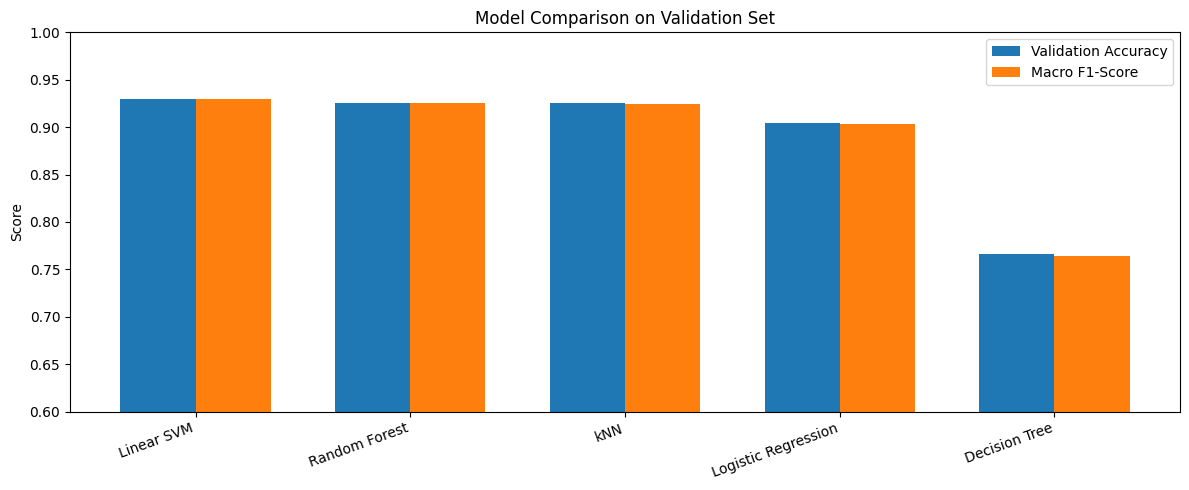

In [27]:
# =====================================================================
# VISUALISE MODEL COMPARISON
# =====================================================================
# Bar chart comparing validation accuracy and macro F1 across models.
# This makes it easy to see which model performs best at a glance.
# =====================================================================
model_names = list(models.keys())
val_accs = [m.score(X_valid, y_valid) for m in models.values()]
f1_scores = [
    f1_score(y_valid, m.predict(X_valid), average='macro')
    for m in models.values()
]

x_pos = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x_pos - width/2, val_accs, width, label='Validation Accuracy')
bars2 = ax.bar(x_pos + width/2, f1_scores, width, label='Macro F1-Score')

ax.set_ylabel('Score')
ax.set_title('Model Comparison on Validation Set')
ax.set_xticks(x_pos)
ax.set_xticklabels([n.replace(' (tuned)', '') for n in model_names], rotation=20, ha='right')
ax.legend()
ax.set_ylim(0.6, 1.0)  # zoom in on the interesting range
plt.tight_layout()
plt.show()

---
## Final Evaluation on Test Set

**Important:** The test set should only be used ONCE, at the very end, to get an unbiased estimate of how the chosen model will perform on truly unseen data.

We select the best-performing model from the validation comparison above and evaluate it on the held-out test set.

In [28]:
# =====================================================================
# SELECT BEST MODEL AND EVALUATE ON TEST SET
# =====================================================================
# Pick the model with the highest validation accuracy.
# Then report its performance on the test set — this is the final,
# unbiased estimate of generalisation performance.
# =====================================================================

# Find the best model by validation accuracy
best_model_name = max(models, key=lambda name: models[name].score(X_valid, y_valid))
best_model = models[best_model_name]

print(f"Selected model: {best_model_name}")
print(f"Validation accuracy: {best_model.score(X_valid, y_valid):.4f}")
print(f"\n--- FINAL TEST SET EVALUATION ---")
print(f"Test accuracy: {best_model.score(X_test, y_test):.4f}")

y_pred_test = best_model.predict(X_test)

print(f"\nTest Macro F1: {f1_score(y_test, y_pred_test, average='macro'):.4f}")

print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test))

Selected model: Linear SVM (tuned)
Validation accuracy: 0.9300

--- FINAL TEST SET EVALUATION ---
Test accuracy: 0.9230

Test Macro F1: 0.9228

Confusion Matrix (Test Set):
[[99  0  0  0  0  1  0  0  0  0]
 [ 0 96  1  0  0  2  0  0  0  1]
 [ 1  1 85  0  5  0  2  0  5  1]
 [ 0  0  5 85  1  4  0  2  2  1]
 [ 0  0  0  0 97  0  0  0  0  3]
 [ 1  0  0  2  2 93  2  0  0  0]
 [ 0  0  1  0  1  1 97  0  0  0]
 [ 0  2  0  0  4  0  0 93  0  1]
 [ 0  1  5  0  0  6  0  0 87  1]
 [ 0  0  0  1  1  1  0  6  0 91]]

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       100
           1       0.96      0.96      0.96       100
           2       0.88      0.85      0.86       100
           3       0.97      0.85      0.90       100
           4       0.87      0.97      0.92       100
           5       0.86      0.93      0.89       100
           6       0.96      0.97      0.97       100
           7       0.92     

---
## Summary & Key Takeaways

### Workflow (use this pattern in the exam):
1. **Load & explore** the data (shapes, class distribution, visualise samples)
2. **Preprocess**: scale features if needed (essential for kNN, SVM, logistic regression)
3. **Split**: train / validation / test (or use cross-validation on train+valid)
4. **Build multiple models** with default hyperparameters
5. **Tune hyperparameters** using `GridSearchCV` with cross-validation on training data
6. **Compare models** on the validation set using accuracy, F1, confusion matrix
7. **Select the best model** and do a final evaluation on the test set

### Key Metrics:
- **Accuracy**: overall fraction correct (can be misleading if classes are imbalanced)
- **Precision**: of all samples predicted as class X, what fraction actually are? (low precision = many false positives)
- **Recall**: of all actual class X samples, what fraction did we catch? (low recall = many false negatives)
- **F1-score**: harmonic mean of precision and recall — good single metric when you care about both
- **Confusion matrix**: shows exactly which classes get mixed up

### Overfitting Indicators:
- Training accuracy much higher than validation accuracy = overfitting
- Decision trees (no depth limit) and RF (unlimited depth) often get 100% training accuracy
- Regularisation (C in SVM/LR, max_depth in trees) is the main tool to combat overfitting

### Model Characteristics:
- **Linear SVM**: Good with high-dimensional data (like images), scales well, needs feature scaling
- **Random Forest**: Robust, handles non-linear boundaries, doesn't need scaling, prone to 100% train acc
- **kNN**: Simple, no training phase, but slow at prediction time with large datasets, very sensitive to feature scaling
- **Logistic Regression**: Fast, interpretable, linear decision boundaries, needs feature scaling
- **Decision Tree**: Interpretable, no scaling needed, but overfits easily without pruning